In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('graphtoken_results.csv')
df_clean = df[df['epochs'] > 1].copy()
sns.set_theme(style="whitegrid")

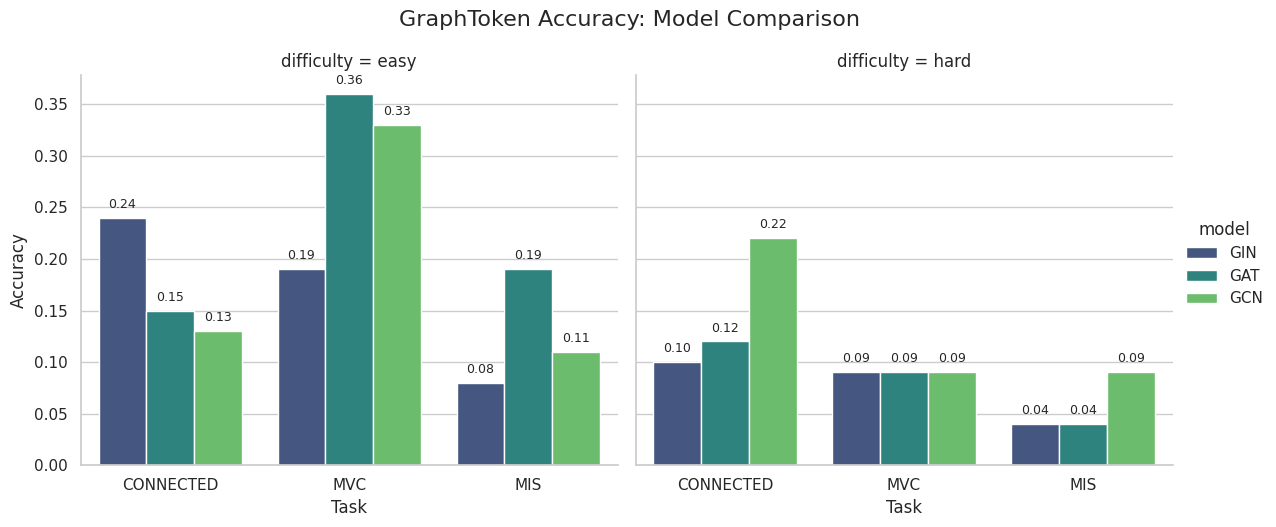

In [4]:
g = sns.catplot(
    data=df_clean,
    x="task",
    y="accuracy",
    hue="model",
    col="difficulty",
    kind="bar",
    palette="viridis",
    height=5,
    aspect=1.2,
    col_order=['easy', 'hard']
)
g.fig.suptitle("GraphToken Accuracy: Model Comparison", y=1.05, fontsize=16)
g.set_axis_labels("Task", "Accuracy")
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 5),
                        textcoords='offset points')
plt.show()

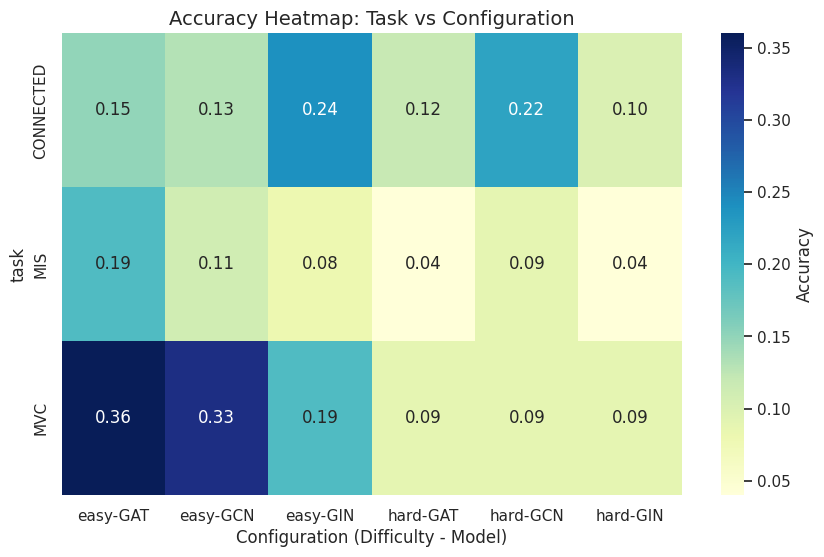

In [5]:
heatmap_data = df_clean.pivot_table(index="task", columns=["difficulty", "model"], values="accuracy")
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Accuracy'})
plt.title("Accuracy Heatmap: Task vs Configuration", fontsize=14)
plt.xlabel("Configuration (Difficulty - Model)")
plt.show()

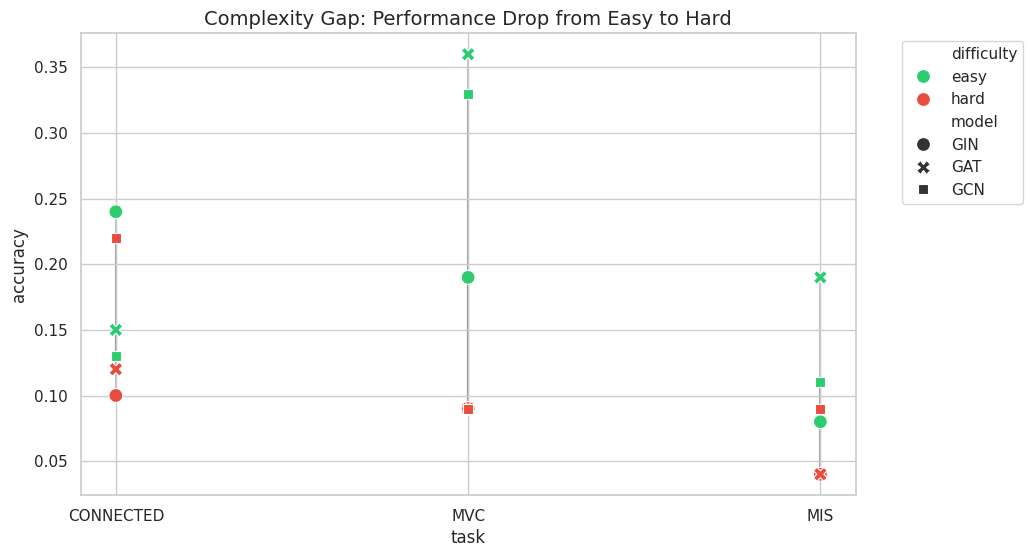

In [6]:
plt.figure(figsize=(10, 6))
# Plot easy/hard points
sns.scatterplot(data=df_clean, x='task', y='accuracy', hue='difficulty',
                style='model', s=100, palette=['#2ecc71', '#e74c3c'])

# Draw connecting lines
df_gap = df_clean.pivot_table(index=['task', 'model'], columns='difficulty', values='accuracy').reset_index()
for i in range(len(df_gap)):
    row = df_gap.iloc[i]
    plt.plot([row['task'], row['task']], [row['easy'], row['hard']], color='gray', alpha=0.5, zorder=0)

plt.title("Complexity Gap: Performance Drop from Easy to Hard", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()